In [1]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

In [3]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [4]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [5]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [6]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

---


# Creating Visualizations for Data Analysis


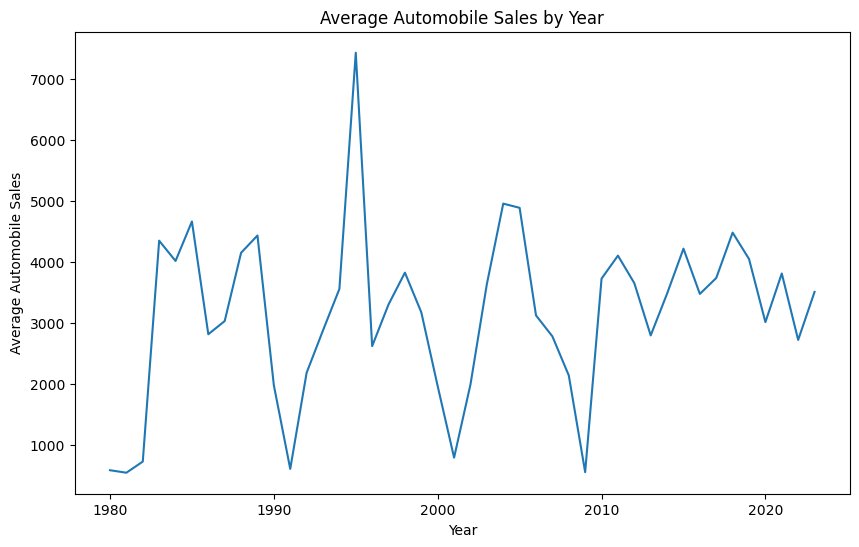

In [7]:
# create data for plotting
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
# create figure
plt.figure(figsize=(10, 6))
df_line.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales by Year')
plt.show()


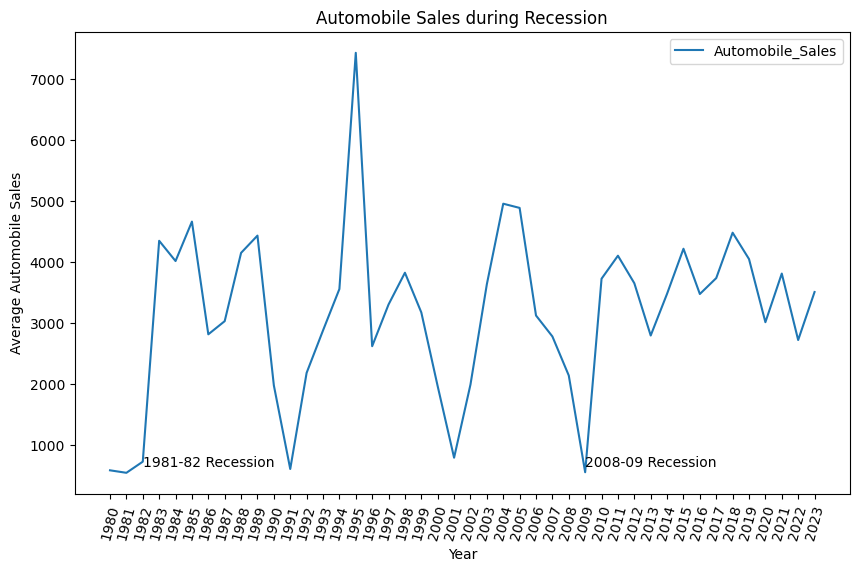

In [8]:
plt.figure(figsize=(10, 6))
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
df_line.plot(kind='line')
plt.xticks(list(range(1980, 2024)), rotation=75)
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')

plt.text(1982, 650, '1981-82 Recession')
plt.text(2009, 650, '2008-09 Recession')

plt.legend()

plt.show()


---



#### 2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.


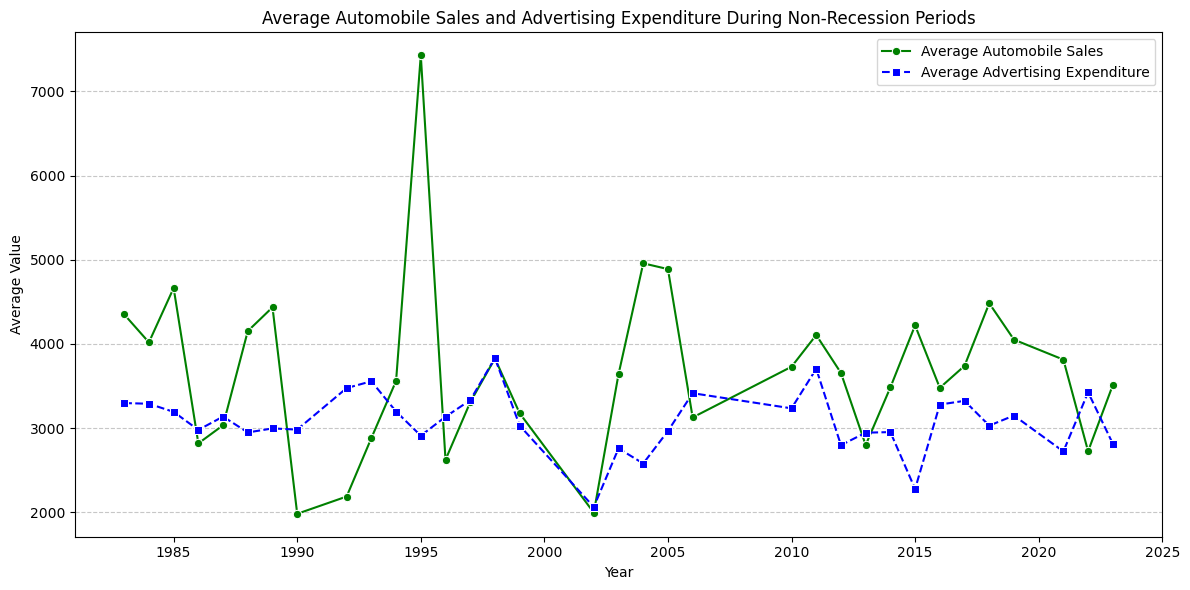

In [ ]:

df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales', marker='o',linestyle='-', color='green',label='Average Automobile Sales')

sns.lineplot(data=df_trends,x='Year',y='Avg_Ad_Spend',marker='s',linestyle='--',color='blue',label='Average Advertising Expenditure')

# Add labels, legend, title, and grid
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Average Automobile Sales and Advertising Expenditure During Non-Recession Periods')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

#### Insights from the above plot, During non-recession periods, automobile sales show greater fluctuations than advertising expenditure. While advertising spending remains relatively stable over time, automobile sales experience several significant increases and decreases. This suggests that although advertising may contribute to sales performance, other factors such as consumer demand, market conditions, and economic trends also have a strong influence on automobile sales. Therefore, the relationship between advertising expenditure and sales appears positive at times but is not consistently strong across all years.


----


### 3. visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.


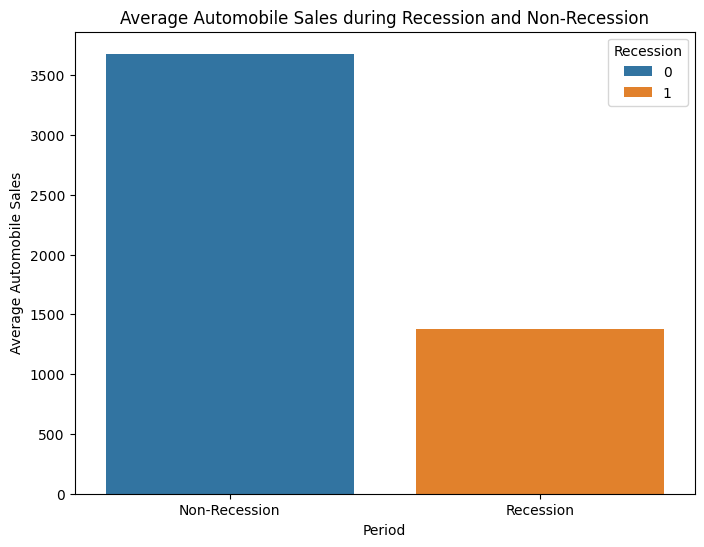

In [19]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession', data=new_df)
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

plt.show()

### comparesion on the sales of different vehicle types during a recession and a non-recession period


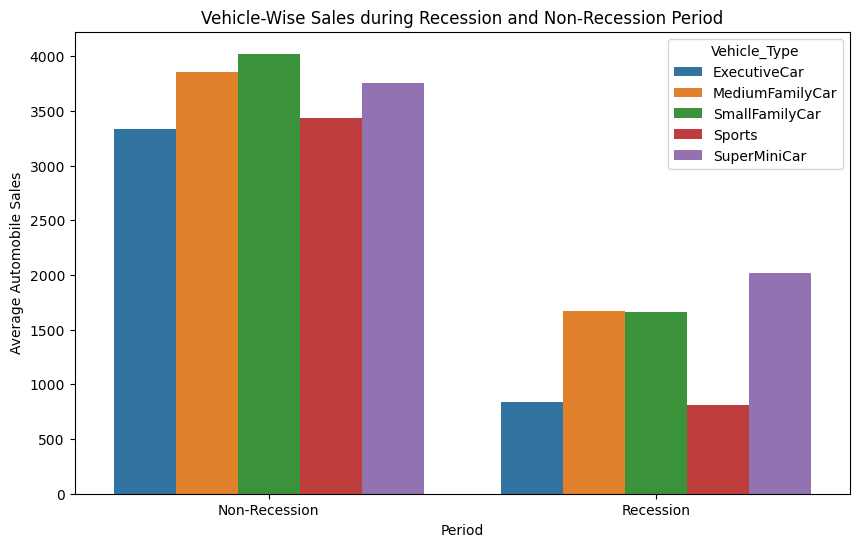

In [20]:
grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Create the grouped bar chart using seaborn
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Recession',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    data=grouped_df
)

plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')

plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

### Insights from the above chart:


The chart shows that sales for all vehicle types decrease during recession periods. SmallFamilyCar and MediumFamilyCar have the highest sales during non-recession periods, while ExecutiveCar and Sports vehicles experience the largest decline during recessions. SuperMiniCar maintains relatively stronger sales during recessions compared to other vehicle types, suggesting that consumers prefer smaller and more affordable vehicles during economic downturns. Overall, recessions have a significant negative impact on automobile sales across all vehicle categories.

---


### 4:compare the variations in GDP during recession and non-recession period by developing line plots for each period.



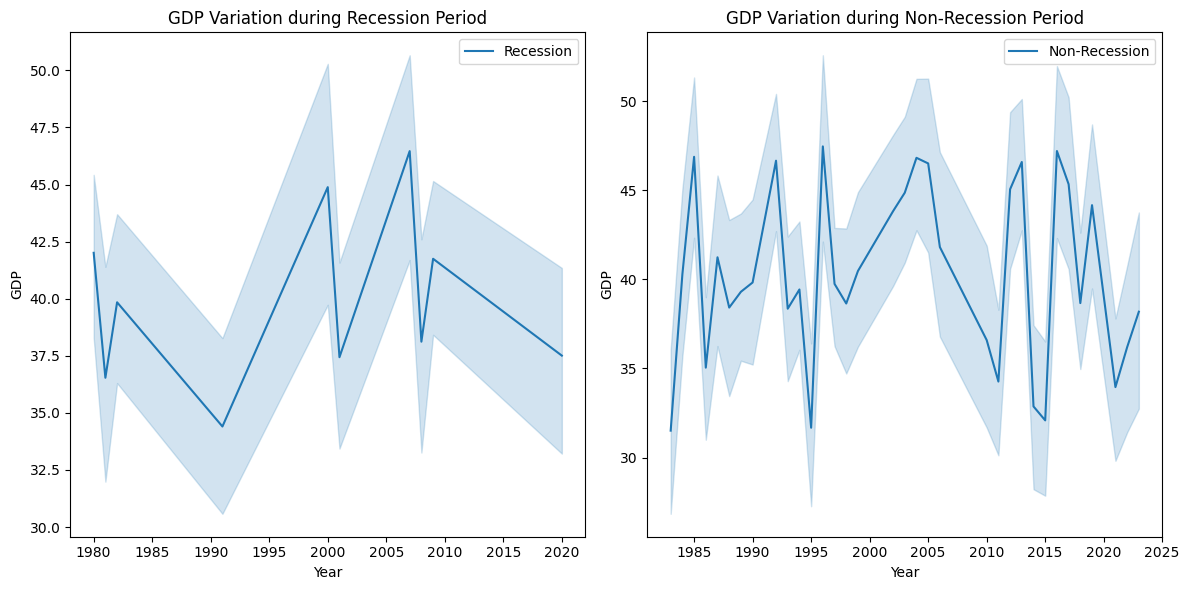

In [12]:
# Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

# Figure
fig = plt.figure(figsize=(12, 6))

# Create different axes for subplots
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

# Recession period
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

# Non-recession period
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()

---


### 5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.



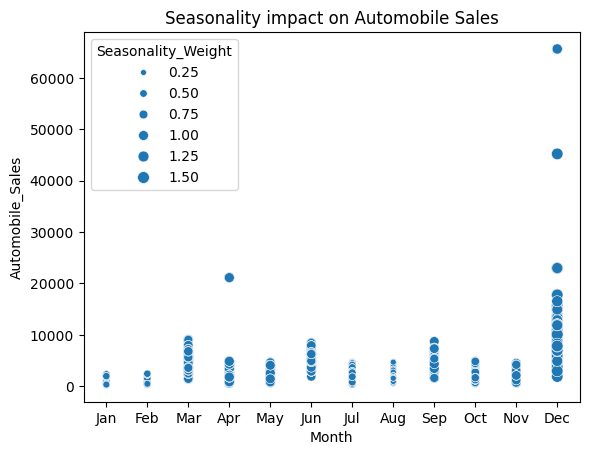

In [13]:
non_rec_data = df[df['Recession'] == 0]

size = non_rec_data['Seasonality_Weight']  # for bubble effect

sns.scatterplot(
    data=non_rec_data,
    x='Month',
    y='Automobile_Sales',
    size=size
)

# you can further include hue='Seasonality_Weight', legend=False

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

---


 ### 6: a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.



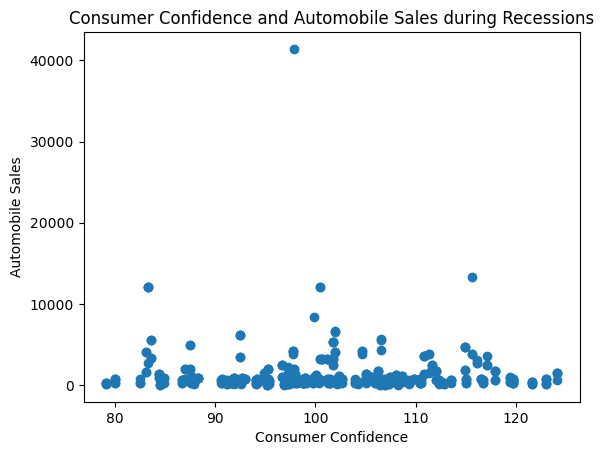

In [14]:
# Create dataframe for recession period
rec_data = df[df['Recession'] == 1]

plt.scatter(rec_data['Consumer_Confidence'],
            rec_data['Automobile_Sales'])

plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')

plt.show()


 ### How does consumer confidence relate to automobile sales during recessions?


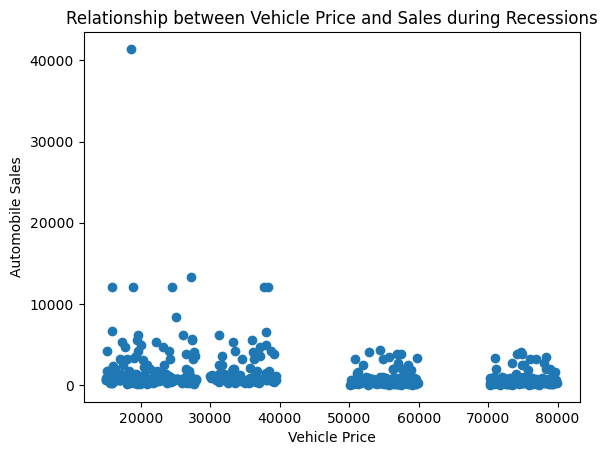

In [15]:
# Create dataframe for recession period
rec_data = df[df['Recession'] == 1]

plt.scatter(rec_data['Price'],
            rec_data['Automobile_Sales'])

plt.xlabel('Vehicle Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')

plt.show()

----


 ### 7:a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.



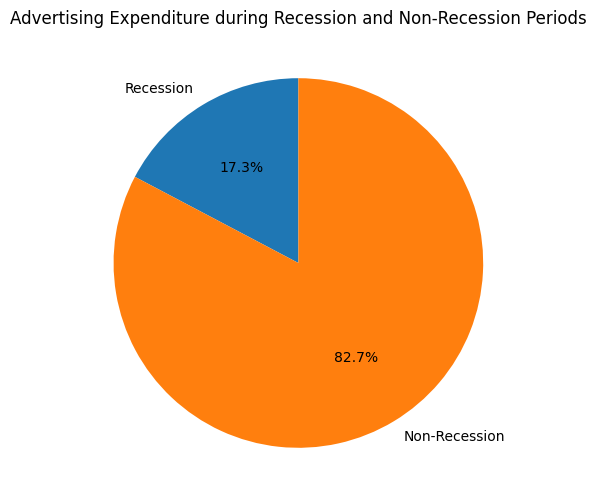

In [17]:
# Filter the data
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure during Recession and Non-Recession Periods')

plt.show()

#### Insights from the above plot:


The pie chart shows that advertising expenditure is significantly higher during non-recession periods than during recession periods. This suggests that the company reduces its advertising budget during economic downturns, likely due to lower demand and cost-saving measures.

---


### 8:  a pie chart display the total Advertisement expenditure for each vehicle type during recession period.


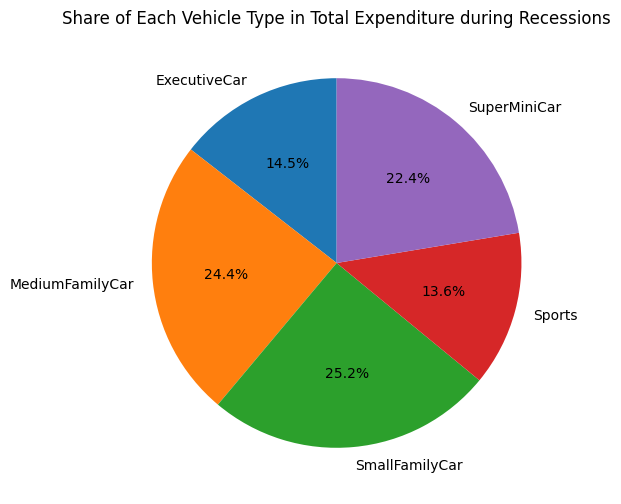

In [18]:
# Filter the data
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(8, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Share of Each Vehicle Type in Total Expenditure during Recessions')

plt.show()

----


 ### 9: a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.


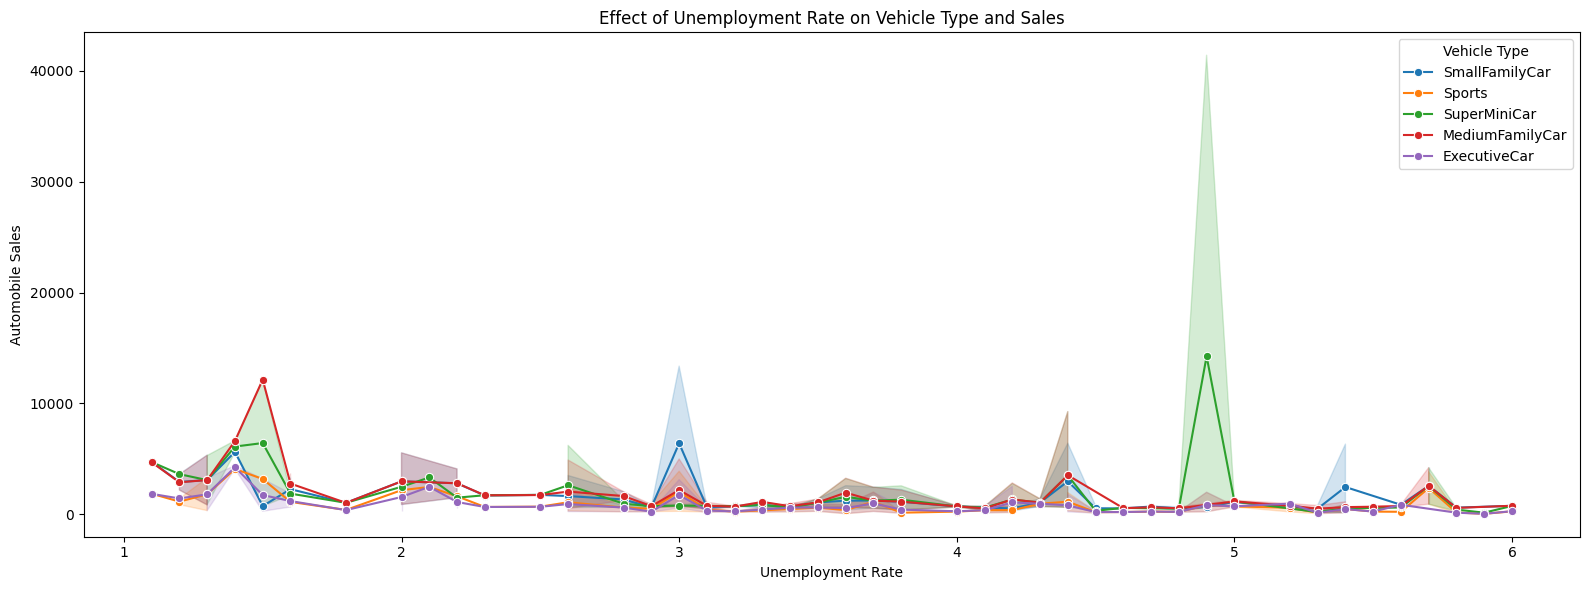

In [ ]:

df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    marker='o'
)

# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')

# Show plot
plt.tight_layout()
plt.show()

#### From the above plot, what insights have you gained on the sales of superminicar, smallfamilycar, mediumminicar?<br> Type your answer below:-


The plot shows that sales of SuperMiniCar, SmallFamilyCar, and MediumFamilyCar are generally higher than other vehicle types during recession periods. Among them, SuperMiniCar exhibits the highest sales peaks, suggesting that consumers prefer smaller and more affordable vehicles when unemployment rates increase. As unemployment rises, sales tend to fluctuate but remain relatively stronger for economy-oriented vehicle types compared to luxury vehicles. This indicates that budget-friendly cars are more resilient during economic downturns.